# 04 — Avaliação e Interpretação

**Dimensão 6 da rúbrica — 20 pontos.**

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

TARGET = "IS_BAD_PAYER"
RANDOM_STATE = 42
RESULTS_DIR = Path("../data/processed")
METRICS_CSV = RESULTS_DIR / "resultados_resampling.csv"
PREDICTIONS_CSV = RESULTS_DIR / "previsoes_resampling.csv"
IMPORTANCES_CSV = RESULTS_DIR / "importancias_resampling.csv"

pd.set_option("display.max_columns", None)

## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada.

Modelo selecionado pelo F1 de mau pagador: random_forest / undersampling_70_30


,estrategia,modelo,accuracy,roc_auc,f1_mau_pagador,precisao_mau_pagador,recall_mau_pagador,balanced_accuracy
7,undersampling_70_30,random_forest,0.870680,0.846835,0.459599,0.452086,0.467366,0.695915
0,oversampling_70_30,random_forest,0.909490,0.866567,0.436860,0.815287,0.298368,0.644677
5,oversampling_70_30,knn,0.840510,0.737870,0.429622,0.370872,0.510490,0.697505
10,undersampling_70_30,knn,0.809243,0.769380,0.392842,0.314027,0.524476,0.685847
3,oversampling_70_30,svm,0.681980,0.779187,0.355296,0.233297,0.744755,0.709182
11,undersampling_70_30,svm,0.656061,0.768382,0.342078,0.220718,0.759907,0.701060
2,oversampling_70_30,xgboost,0.636039,0.803146,0.338155,0.215102,0.790210,0.702845
8,undersampling_70_30,xgboost,0.593390,0.805263,0.336837,0.208414,0.877622,0.716554
12,undersampling_70_30,logistic_regression,0.671832,0.744899,0.332497,0.218555,0.694639,0.681715
4,oversampling_70_30,logistic_regression,0.664290,0.744614,0.325991,0.213410,0.689977,0.675420


Relatorio de classificacao no conjunto de teste:
              precision    recall  f1-score   support

 Bom pagador       0.93      0.92      0.93      6434
 Mau pagador       0.45      0.47      0.46       858

    accuracy                           0.87      7292
   macro avg       0.69      0.70      0.69      7292
weighted avg       0.87      0.87      0.87      7292



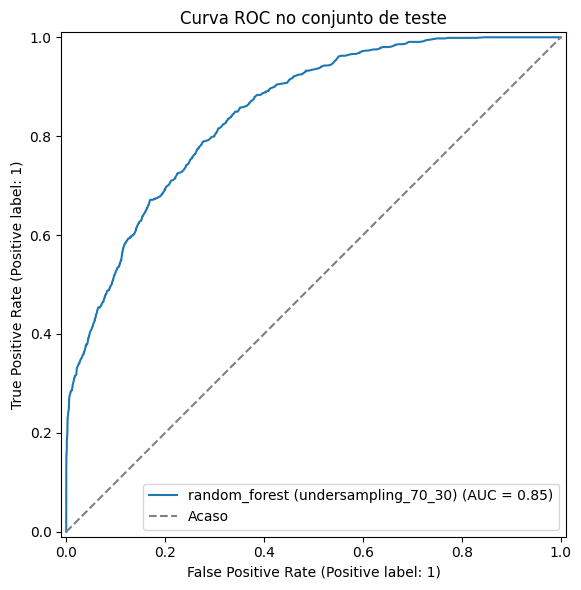

In [11]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
)

resultados_resampling = pd.read_csv(METRICS_CSV)
predicoes_resampling = pd.read_csv(PREDICTIONS_CSV)

# Seleciona a combinacao de modelo e resampling com maior F1 para a classe positiva.
melhor_resultado = resultados_resampling.loc[
    resultados_resampling["f1_mau_pagador"].idxmax()
]
mascara_melhor = (
    (predicoes_resampling["estrategia"] == melhor_resultado["estrategia"])
    & (predicoes_resampling["modelo"] == melhor_resultado["modelo"])
)
predicoes_melhor = predicoes_resampling.loc[mascara_melhor].copy()
y_test = predicoes_melhor["y_true"]
y_pred = predicoes_melhor["y_pred"]
y_score = predicoes_melhor["score_mau_pagador"]

print(
    "Modelo selecionado pelo F1 de mau pagador: "
    f"{melhor_resultado['modelo']} / {melhor_resultado['estrategia']}"
)
display(resultados_resampling.sort_values("f1_mau_pagador", ascending=False))
print("Relatorio de classificacao no conjunto de teste:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Bom pagador", "Mau pagador"],
    zero_division=0,
))

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    y_score,
    name=f"{melhor_resultado['modelo']} ({melhor_resultado['estrategia']})",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Acaso")
ax.set_title("Curva ROC no conjunto de teste")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 2. Justificativa das métricas

A acurácia mostra a fração total de previsões corretas, mas pode parecer alta mesmo quando o modelo quase nunca identifica a classe minoritária. Por isso, a avaliação também considera precisão, recall, F1, balanced accuracy e ROC AUC para `IS_BAD_PAYER = 1` (mau pagador).

O F1 foi usado para escolher o modelo porque o objetivo principal é identificar maus pagadores (IS_BAD_PAYER = 1) numa base desbalanceada. A acurácia sozinha pode ser enganosa: prever todos como bons já acertaria cerca de 88% dos casos, sem encontrar nenhum mau pagador.

O F1 combina precisão — entre os clientes sinalizados como maus, quantos realmente são — e recall — quantos dos maus pagadores reais foram encontrados:

$$
F1 = 2 \cdot \frac{\text{precisão} \cdot \text{recall}}{\text{precisão} + \text{recall}}
$$
 
Na tabela atual, o Random Forest com undersampling teve o maior F1 para a classe de maus pagadores: 0,460, com precisão 0,452 e recall 0,467. Isso indica um compromisso razoavelmente equilibrado entre não acusar bons pagadores indevidamente e não deixar passar maus pagadores.

A escolha depende, porém, do custo de cada erro. Se a prioridade for detectar o máximo possível de maus pagadores, pode fazer mais sentido escolher pelo recall; se for evitar rejeitar bons clientes, pela precisão. Para ordenar clientes por risco em diferentes limiares, ROC AUC é uma alternativa. Portanto, F1 é um critério de seleção coerente com o equilíbrio entre precisão e recall, não uma regra universal

Neste contexto, um falso negativo é um mau pagador classificado como bom, podendo levar a concessão de crédito com maior risco de inadimplência. Um falso positivo é um bom pagador classificado como mau, o que pode significar perder uma oportunidade de negócio e prejudicar o cliente. O custo relativo depende da política de crédito; por isso, precisão e recall devem ser avaliados em conjunto, e o limiar de decisão pode ser ajustado conforme o apetite de risco.

## 3. Matriz de confusão

As linhas representam a classe real e as colunas a classe prevista. Para a classe positiva `IS_BAD_PAYER = 1`, os falsos negativos são maus pagadores que o modelo não sinalizou; os falsos positivos são bons pagadores sinalizados como risco. A célula de código apresenta os totais do modelo e da estratégia selecionados na seção 1.

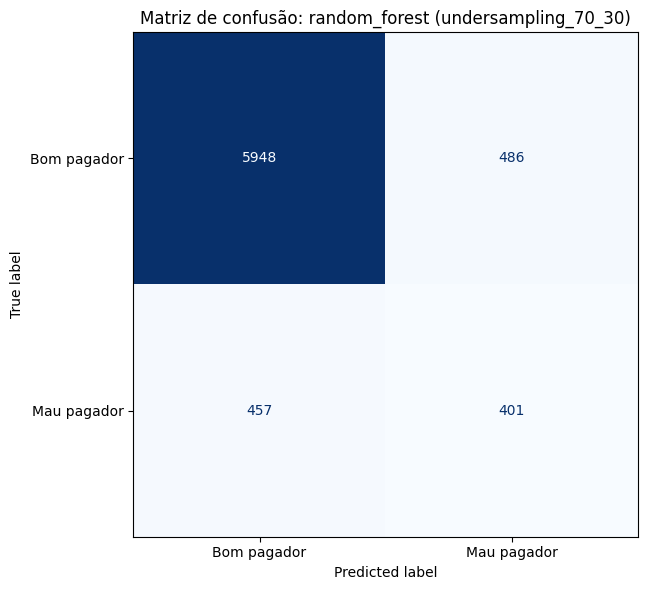

Verdadeiros negativos: 5948
Falsos positivos: 486
Falsos negativos: 457
Verdadeiros positivos: 401


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

matriz_confusao = confusion_matrix(y_test, y_pred, labels=[0, 1])
verdadeiros_negativos, falsos_positivos, falsos_negativos, verdadeiros_positivos = matriz_confusao.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Bom pagador", "Mau pagador"],
).plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title(
    f"Matriz de confusão: {melhor_resultado['modelo']} "
    f"({melhor_resultado['estrategia']})"
)
plt.tight_layout()
plt.show()

print(f"Verdadeiros negativos: {verdadeiros_negativos}")
print(f"Falsos positivos: {falsos_positivos}")
print(f"Falsos negativos: {falsos_negativos}")
print(f"Verdadeiros positivos: {verdadeiros_positivos}")

## 4. Importância das variáveis

A tabela abaixo usa a importância disponível para o modelo selecionado na seção 1. Em modelos de árvore, `feature_importances_` resume quanto cada variável contribuiu para as divisões das árvores; para regressão logística, usa-se a magnitude média absoluta dos coeficientes. Essas medidas ajudam a interpretar o modelo, mas não demonstram causalidade e podem repartir importância entre variáveis correlacionadas.

,estrategia,modelo,variavel,importancia,metodo
41,undersampling_70_30,random_forest,STATUS_LATED,0.153154,feature_importances_
46,undersampling_70_30,random_forest,PROP_LATED,0.113887,feature_importances_
40,undersampling_70_30,random_forest,TOTAL_MOUNTHS_OBSERVED,0.094795,feature_importances_
38,undersampling_70_30,random_forest,YEARS_BIRTH,0.084647,feature_importances_
44,undersampling_70_30,random_forest,INCOME_PER_PERSON,0.079243,feature_importances_
27,undersampling_70_30,random_forest,AMT_INCOME_TOTAL,0.073722,feature_importances_
47,undersampling_70_30,random_forest,PROP_ON_TIME,0.055657,feature_importances_
36,undersampling_70_30,random_forest,OCCUPATION_TYPE,0.051407,feature_importances_
43,undersampling_70_30,random_forest,STATUS_NO_CREDIT,0.043329,feature_importances_
42,undersampling_70_30,random_forest,STATUS_ON_TIME,0.041491,feature_importances_


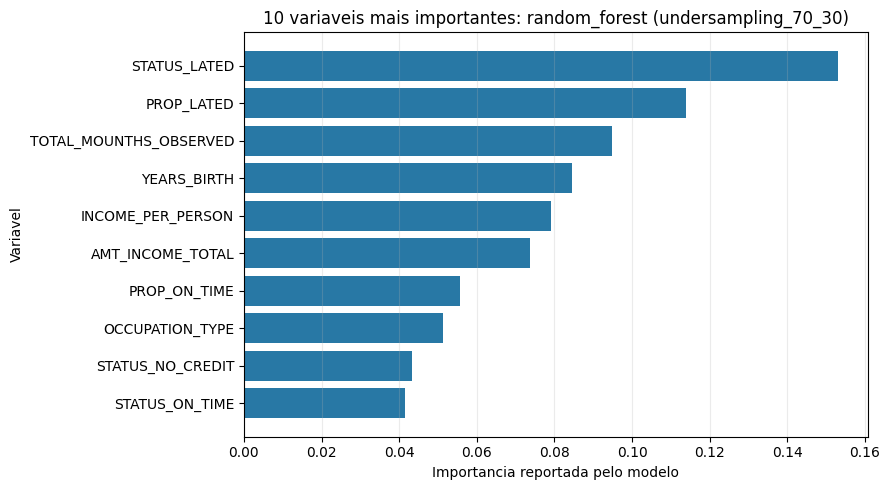

Variaveis mais importantes, em ordem:
STATUS_LATED, PROP_LATED, TOTAL_MOUNTHS_OBSERVED, YEARS_BIRTH, INCOME_PER_PERSON


In [13]:
importancias_resampling = pd.read_csv(IMPORTANCES_CSV)
importancias_melhor = importancias_resampling.loc[
    (importancias_resampling["estrategia"] == melhor_resultado["estrategia"])
    & (importancias_resampling["modelo"] == melhor_resultado["modelo"])
].sort_values("importancia", ascending=False)

if importancias_melhor.empty:
    print(
        "Nao ha importancia intrinseca exportada para o modelo selecionado. "
        "O modelo pode nao expor feature_importances_ nem coeficientes."
    )
else:
    display(importancias_melhor.head(10))
    top_variaveis = importancias_melhor.head(10).sort_values("importancia")

    fig, ax = plt.subplots(figsize=(9, max(5, len(top_variaveis) * 0.4)))
    ax.barh(top_variaveis["variavel"], top_variaveis["importancia"], color="#2878a5")
    ax.set_title(
        f"10 variaveis mais importantes: {melhor_resultado['modelo']} "
        f"({melhor_resultado['estrategia']})"
    )
    ax.set_xlabel("Importancia reportada pelo modelo")
    ax.set_ylabel("Variavel")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    print("Variaveis mais importantes, em ordem:")
    print(", ".join(importancias_melhor.head(5)["variavel"].tolist()))

## 5. Implicações práticas

_O que alguém da área faria de diferente a partir destes resultados?
Escreva sem jargão — este texto é a base do vídeo executivo._

## 6. Limitações

_Onde o modelo falha e o que você faria com mais tempo ou mais dados._